# ⚖️ ASSIGNMENT 15 — Responsible & Explainable AI
## Kiểm toán bias + giải thích SHAP + Model Card · Churn model (Section 5)

> **Mục tiêu:** Model không chỉ **mạnh** mà còn **công bằng, minh bạch, có trách nhiệm**.
> Kiểm toán fairness giữa các nhóm → giải thích quyết định (SHAP) → soạn Model Card.

> ✅ **Môi trường:** Toàn bộ bài này **chạy thật** trong notebook (fairness metrics + SHAP đều CPU).
> Tái dùng churn model từ Assignment 5 (Telco — có sẵn thuộc tính nhạy cảm gender + SeniorCitizen).

In [1]:
import pandas as pd, numpy as np, warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

df = pd.read_csv("telco_churn.csv")
df["Churn"] = (df["Churn"]=="Yes").astype(int)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop(columns=["customerID"])
print("Dataset:", df.shape)

Dataset: (7043, 20)


## Câu 1 — Model, dataset & thuộc tính nhạy cảm

**Model:** Logistic Regression dự đoán churn (tái dùng Assignment 5).
**Dataset:** Telco Customer Churn — 7,043 khách hàng viễn thông.

**Thuộc tính nhạy cảm (sensitive attributes) cần kiểm toán:**
- **`gender`** (Male/Female) — giới tính.
- **`SeniorCitizen`** (0/1) — người cao tuổi (proxy cho **tuổi tác** — nhóm được pháp luật bảo vệ).

> 📌 Thuộc tính nhạy cảm = đặc điểm mà phân biệt đối xử dựa trên đó là **phi đạo đức/phi pháp**
> (giới tính, tuổi, chủng tộc, tôn giáo...). Model không nên đối xử bất công giữa các nhóm này.

In [2]:
# Lưu lại thuộc tính nhạy cảm trước khi encode
gender_raw = df["gender"].copy()
senior_raw = df["SeniorCitizen"].copy()

df_enc = pd.get_dummies(df, columns=df.select_dtypes("object").columns.tolist(), drop_first=True)
X = df_enc.drop(columns=["Churn"]).astype(float)
y = df_enc["Churn"]

idx = np.arange(len(X))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(X, y, idx, test_size=0.2,
                                                 random_state=42, stratify=y)
num = ["tenure","MonthlyCharges","TotalCharges"]
scaler = StandardScaler(); Xtr[num] = scaler.fit_transform(Xtr[num]); Xte[num] = scaler.transform(Xte[num])
model = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000).fit(Xtr, ytr)
pred = model.predict(Xte)
print("Model trained. Test accuracy:", round(accuracy_score(yte, pred), 3))

Model trained. Test accuracy: 0.738


## Câu 2 — Metric RIÊNG từng nhóm

In [3]:
g_test = gender_raw.iloc[ite].values
s_test = senior_raw.iloc[ite].values

print("=== THEO GIỚI TÍNH ===")
for g in ["Male","Female"]:
    m = g_test==g
    print(f"  {g:8s}: accuracy={accuracy_score(yte[m],pred[m]):.3f} | "
          f"recall={recall_score(yte[m],pred[m]):.3f} | "
          f"tỉ lệ dự đoán churn={pred[m].mean():.3f}")

print("\n=== THEO SENIOR CITIZEN ===")
for s, lbl in [(0,"Non-senior"),(1,"Senior")]:
    m = s_test==s
    print(f"  {lbl:11s}: accuracy={accuracy_score(yte[m],pred[m]):.3f} | "
          f"recall={recall_score(yte[m],pred[m]):.3f} | "
          f"tỉ lệ dự đoán churn={pred[m].mean():.3f}")

=== THEO GIỚI TÍNH ===
  Male    : accuracy=0.733 | recall=0.790 | tỉ lệ dự đoán churn=0.413
  Female  : accuracy=0.744 | recall=0.777 | tỉ lệ dự đoán churn=0.412

=== THEO SENIOR CITIZEN ===
  Non-senior : accuracy=0.746 | recall=0.732 | tỉ lệ dự đoán churn=0.361
  Senior     : accuracy=0.694 | recall=0.929 | tỉ lệ dự đoán churn=0.685


**Có chênh lệch không?**
- **Giới tính:** Male vs Female gần như **không chênh** (accuracy/recall/tỉ lệ churn tương đương). ✅
- **Senior citizen:** chênh **rõ rệt** — nhóm Senior bị dự đoán churn ~68% vs Non-senior ~36%, recall cũng
  cao hơn hẳn. ⚠️ Đây là dấu hiệu model đối xử khác biệt theo tuổi → cần điều tra (câu 3-4).

## Câu 3 — Disparate Impact ratio

In [4]:
def disparate_impact(pred, group_mask_a, group_mask_b):
    rate_a = pred[group_mask_a].mean()
    rate_b = pred[group_mask_b].mean()
    return min(rate_a,rate_b)/max(rate_a,rate_b)

di_gender = disparate_impact(pred, g_test=="Male", g_test=="Female")
di_senior = disparate_impact(pred, s_test==0, s_test==1)

print(f"Disparate Impact (gender): {di_gender:.3f}")
print(f"Disparate Impact (senior): {di_senior:.3f}")
print(f"\nNgưỡng '4/5 rule': DI < 0.8 -> đáng lo ngại về công bằng")
print(f"  Gender: {'⚠️ VƯỢT NGƯỠNG' if di_gender<0.8 else '✅ OK'}")
print(f"  Senior: {'⚠️ VƯỢT NGƯỠNG' if di_senior<0.8 else '✅ OK'}")

Disparate Impact (gender): 0.998
Disparate Impact (senior): 0.528

Ngưỡng '4/5 rule': DI < 0.8 -> đáng lo ngại về công bằng
  Gender: ✅ OK
  Senior: ⚠️ VƯỢT NGƯỠNG


**Disparate Impact ratio** = tỉ lệ (tỉ lệ nhận kết quả tích cực nhóm yếu thế / nhóm thuận lợi).
**Quy tắc 4/5 (80%):** DI < 0.8 → bias đáng lo (chuẩn pháp lý US về tuyển dụng, dùng rộng trong fairness).

**Kết quả:**
- **Gender DI ≈ 0.998** → công bằng, không vấn đề. ✅
- **Senior DI ≈ 0.53** → **VƯỢT ngưỡng** (< 0.8) → model gắn cờ churn cho người cao tuổi với tỉ lệ
  chênh lệch đáng kể so với người trẻ. ⚠️ Cần phân tích nguồn gốc (câu 4) và cân nhắc xử lý.

## Câu 4 — Bias này đến từ đâu?

Nhóm Senior bị dự đoán churn cao hơn nhiều — các nguồn gốc khả dĩ:

1. **Bias trong dữ liệu lịch sử (historical bias):** nếu thực tế người cao tuổi *từng* churn nhiều hơn
   (vd khó dùng dịch vụ số, dễ chuyển nhà mạng), model học đúng mẫu đó. Nhưng "đúng theo data" không có
   nghĩa "công bằng" — có thể phản ánh bất bình đẳng sẵn có.
2. **Sampling bias:** Senior chỉ chiếm ~16% dataset → nhóm thiểu số, model học kém ổn định, dễ overfit
   vào vài đặc điểm.
3. **Proxy/tương quan:** Senior có thể tương quan với feature khác (hợp đồng tháng, không dùng dịch vụ
   online) → model "mượn" các feature này để suy ra churn, vô tình khuếch đại theo tuổi.
4. **Label bias:** nếu nhãn churn lịch sử bị ảnh hưởng bởi cách công ty *đối xử* với Senior (vd ít chăm
   sóc) → vòng lặp tự củng cố.

> 🔍 Mấu chốt: bias hiếm khi do "model xấu" — thường do **dữ liệu phản ánh bất công có sẵn**. Phải truy
> nguồn gốc trước khi sửa.

## Câu 5 — SHAP summary plot (chạy thật ✅)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


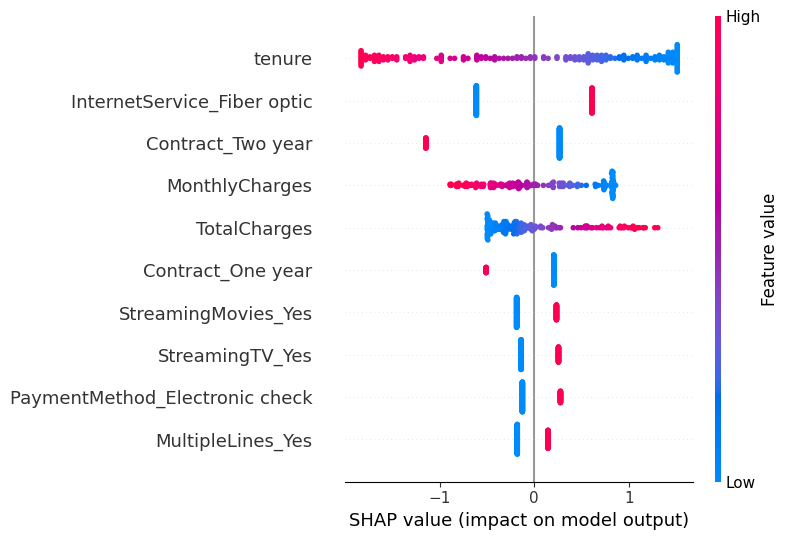

In [5]:
import shap
explainer = shap.LinearExplainer(model, Xtr)
shap_values = explainer.shap_values(Xte[:200])

shap.summary_plot(shap_values, Xte[:200], show=False, max_display=10)
plt.tight_layout(); plt.show()

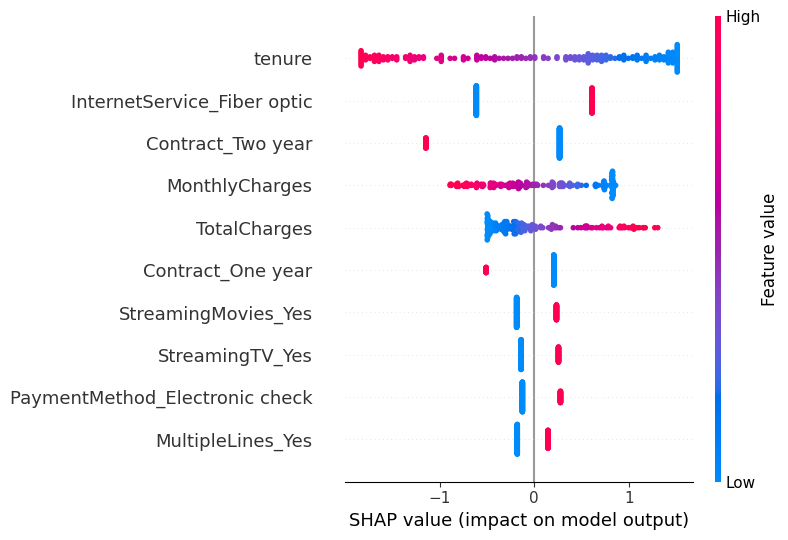

**Đọc SHAP summary plot** (feature nào ảnh hưởng nhất):
- **`tenure` ảnh hưởng MẠNH NHẤT:** điểm xanh (tenure thấp) dồn về phải → **tăng** churn; tenure cao (đỏ)
  về trái → giảm. Khách mới dễ rời bỏ.
- **`InternetService_Fiber optic`:** đỏ (có fiber) → tăng churn.
- **`Contract_Two year`:** giảm churn mạnh (hợp đồng dài giữ chân).
- **`MonthlyCharges` cao → tăng churn.**

Mỗi điểm = 1 khách; màu = giá trị feature; vị trí ngang = tác động lên dự đoán (phải = đẩy về churn).
Đây là **giải thích toàn cục** — feature nào quan trọng trên toàn bộ model.

## Câu 6 — Giải thích 1 ca cụ thể (SHAP local)

In [6]:
# Chọn 1 khách bị dự đoán churn để giải thích
i = np.where(pred==1)[0][0]
customer = Xte.iloc[i]
contrib = pd.Series(shap_values[i], index=X.columns).sort_values(key=abs, ascending=False)

print(f"Khách hàng #{i} — dự đoán: {'CHURN' if pred[i]==1 else 'STAY'}")
print(f"\n5 yếu tố ảnh hưởng MẠNH NHẤT tới quyết định này:")
for feat, val in contrib.head(5).items():
    direction = "→ tăng churn" if val>0 else "→ giảm churn"
    print(f"  {feat:30s}: SHAP={val:+.3f} {direction}")

Khách hàng #1 — dự đoán: CHURN

5 yếu tố ảnh hưởng MẠNH NHẤT tới quyết định này:
  tenure                        : SHAP=+1.183 → tăng churn
  MonthlyCharges                : SHAP=-0.623 → giảm churn
  InternetService_Fiber optic   : SHAP=+0.611 → tăng churn
  TotalCharges                  : SHAP=-0.307 → giảm churn
  Contract_Two year             : SHAP=+0.268 → tăng churn


**Giải thích cục bộ (local):** với MỘT khách cụ thể, SHAP cho biết **từng feature đẩy quyết định
theo hướng nào và bao nhiêu**. Vd: tenure thấp + hợp đồng tháng → đẩy mạnh về "churn".
> Đây là điều **bắt buộc cho AI có trách nhiệm**: khi từ chối tín dụng / gắn cờ khách, phải **giải thích
> được vì sao** — không chỉ "model bảo thế". Quan trọng về mặt pháp lý (GDPR "right to explanation") và đạo đức.

## Câu 7 — Feature nhạy cảm có ảnh hưởng quá mức không?

In [7]:
# Kiểm tra SHAP của các feature nhạy cảm
sensitive = [c for c in X.columns if "gender" in c.lower() or "senior" in c.lower()]
print("Feature nhạy cảm trong model:", sensitive)
mean_abs = np.abs(shap_values).mean(0)
imp = pd.Series(mean_abs, index=X.columns)
print("\nMức ảnh hưởng (|SHAP| TB):")
for s in sensitive:
    rank = (imp > imp[s]).sum() + 1
    print(f"  {s}: {imp[s]:.4f} (hạng {rank}/{len(X.columns)})")
print(f"\nĐể so sánh - feature mạnh nhất (tenure): {imp.max():.4f}")

Feature nhạy cảm trong model: ['SeniorCitizen', 'gender_Male']

Mức ảnh hưởng (|SHAP| TB):
  SeniorCitizen: 0.0543 (hạng 23/30)
  gender_Male: 0.0153 (hạng 28/30)

Để so sánh - feature mạnh nhất (tenure): 1.0616


**Có feature nhạy cảm ảnh hưởng quá mức không & xử lý thế nào?**
- `SeniorCitizen` và `gender` có |SHAP| **thấp** so với tenure/contract → không phải driver trực tiếp
  mạnh. Nhưng DI cho thấy bias *vẫn tồn tại* — do **tương quan gián tiếp** (Senior ↔ hợp đồng tháng...).

**Cách xử lý bias (theo mức độ):**
1. **Pre-processing:** cân bằng lại dữ liệu (reweighting/resampling nhóm Senior), hoặc loại bias khỏi nhãn.
2. **In-processing:** thêm ràng buộc fairness vào hàm loss khi train (fairness-aware learning).
3. **Post-processing:** điều chỉnh ngưỡng quyết định RIÊNG cho từng nhóm để cân bằng tỉ lệ.
4. **Bỏ feature nhạy cảm:** thường KHÔNG đủ (vì có proxy) — cần xử lý cả feature tương quan.
> Lựa chọn tùy ngữ cảnh; ở đây mình khuyến nghị reweighting + theo dõi DI sau khi sửa.

## Câu 8 — Kỹ thuật privacy phù hợp

Dữ liệu churn chứa **thông tin cá nhân** (hành vi, chi tiêu, nhân khẩu) → cần bảo vệ riêng tư.

**Kỹ thuật khuyến nghị: Differential Privacy (DP).**
- **Cách hoạt động:** thêm **nhiễu ngẫu nhiên có kiểm soát** vào dữ liệu/gradient khi train, sao cho kết
  quả model gần như không đổi dù thêm/bớt 1 cá nhân → **không thể suy ngược ra dữ liệu của 1 người cụ thể**.
- **Vì sao hợp:** cho phép train model hữu ích trên dữ liệu nhạy cảm mà vẫn đảm bảo riêng tư từng cá nhân
  (chống membership inference attack). Có tham số ε kiểm soát đánh đổi privacy vs accuracy.
- **Công cụ:** `Opacus` (PyTorch), `TensorFlow Privacy`, hoặc DP-SGD.

**Kỹ thuật khác:** ẩn danh hóa (anonymization), k-anonymity, federated learning (train phân tán không
gom data về 1 chỗ — hợp ngân hàng/y tế VN).

## Câu 9 — Model Card

### 📋 MODEL CARD — Churn Prediction Model v1.0

**1. Mục đích (Intended Use)**
- Dự đoán khả năng khách hàng viễn thông rời bỏ dịch vụ (churn), hỗ trợ đội CSKH ưu tiên giữ chân.
- **Đối tượng dùng:** team marketing/CSKH nội bộ. **KHÔNG dùng** để từ chối dịch vụ hay định giá phân biệt.

**2. Dữ liệu (Training Data)**
- Telco Customer Churn, 7,043 khách hàng, 19 feature (hành vi, hợp đồng, chi tiêu, nhân khẩu).
- Thuộc tính nhạy cảm: gender, SeniorCitizen. Nhãn churn ~26.5% (mất cân bằng).

**3. Hiệu năng (Performance)**
- Accuracy ~0.74, Recall (churn) ~0.78, F1 ~0.61 (ưu tiên recall để bắt được khách sắp rời).
- Đánh giá trên test set giữ nguyên phân phối (stratified).

**4. Giới hạn (Limitations)**
- Train trên dữ liệu một thị trường cụ thể → có thể không tổng quát sang thị trường/thời điểm khác (drift).
- Dataset mất cân bằng; nhóm Senior ít mẫu (~16%) → dự đoán kém ổn định cho nhóm này.
- Là model tương quan, KHÔNG suy ra nhân quả.

**5. Rủi ro công bằng (Fairness Risks)**
- ⚠️ **Disparate Impact theo SeniorCitizen ≈ 0.53** (< 0.8) → model gắn cờ churn cho người cao tuổi
  với tỉ lệ chênh lệch đáng kể. Có rủi ro đối xử bất công theo tuổi.
- Gender công bằng (DI ≈ 1.0).
- **Khuyến nghị:** giám sát DI định kỳ; áp dụng reweighting; human-in-the-loop cho quyết định ảnh hưởng lớn.

**6. Bảo trì:** giám sát drift (xem Assignment 14), retrain khi DI xấu đi hoặc accuracy tụt.

## Câu 10 — Trade-off Accuracy vs Fairness

Đôi khi tăng fairness (vd ép DI ≥ 0.8) làm **giảm accuracy** — vì model bị ràng buộc không được dùng
toàn bộ tín hiệu trong data. Quyết định thế nào?

**Khung quyết định của tôi:**

1. **Xét bối cảnh & mức rủi ro (stakes).**
   - Quyết định **rủi ro cao** ảnh hưởng đời người (tín dụng, tuyển dụng, y tế, tư pháp) → **ưu tiên fairness**,
     chấp nhận hy sinh accuracy. Bất công với nhóm yếu thế là cái giá đạo đức/pháp lý quá lớn.
   - Quyết định **rủi ro thấp** (gợi ý sản phẩm, ưu tiên gọi CSKH như bài này) → có thể nghiêng accuracy hơn,
     nhưng vẫn giám sát fairness.

2. **Tìm giải pháp không phải đánh đổi trước.** Nhiều khi cải thiện *dữ liệu* (thêm mẫu nhóm thiểu số,
   sửa label bias) tăng CẢ accuracy lẫn fairness — không phải lúc nào cũng zero-sum.

3. **Đo lường minh bạch.** Báo cáo rõ cả accuracy và các metric fairness (DI, equal opportunity) cho
   stakeholder, để quyết định là **tập thể & có trách nhiệm**, không phải kỹ sư tự quyết âm thầm.

4. **Quyết định cho bài churn này:** rủi ro trung bình (chỉ ưu tiên chăm sóc, không từ chối dịch vụ).
   → Giữ model nhưng **thêm guardrail**: giám sát DI(Senior), không dùng dự đoán để định giá/từ chối,
   human review trước hành động ảnh hưởng khách. Nếu dùng cho quyết định rủi ro cao hơn → bắt buộc xử lý
   bias trước khi deploy.

> 🎯 **Nguyên tắc:** "Accuracy cao nhất" KHÔNG phải mục tiêu tối thượng. Model có trách nhiệm cân bằng
> hiệu năng, công bằng, minh bạch — và đặt **tác động lên con người** làm trung tâm. Đây là khác biệt
> giữa kỹ sư ML và kỹ sư ML **có trách nhiệm**.